# Sprint 01 — US 1.1 : Enquête sur les données

Objectif : explorer les CSV bruts, extraire les premières métriques (lignes, colonnes,
doublons, valeurs manquantes) et repérer les enjeux d'anonymisation / de biais.

> **Prérequis** : base PostgreSQL démarrée et couche `bronze` alimentée — exécuter
> d'abord `uv run indusense-ingest --migrate`. Les pipelines d'analyse (incidents /
> télémétrie / référentiel) lisent **bronze** (architecture médaillon) ; le brut n'est
> lu que par l'ingestion.


In [1]:
from indusense.data import loaders

telemetry = loaders.load_telemetry()
incidents = loaders.load_incidents()
telemetry.shape, incidents.shape

((134280, 7), (900, 18))

In [2]:
telemetry.head()

,machine_id,timestamp,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced
0,MACH-01,2025-06-01 00:00:00,45.44,194.302,227.57,1441.7,4
1,MACH-01,2025-06-01 01:00:00,47.87,194.391,227.48,1437.8,4
2,MACH-01,2025-06-01 02:00:00,50.46,195.641,228.68,1484.6,13
3,MACH-01,2025-06-01 03:00:00,48.62,197.737,228.44,1488.9,10
4,MACH-01,2025-06-01 04:00:00,51.09,196.253,227.84,1448.6,6


In [3]:
telemetry.info()
telemetry.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 134280 entries, 0 to 134279
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   machine_id         134280 non-null  str    
 1   timestamp          134280 non-null  str    
 2   temperature_c      134280 non-null  float64
 3   pressure_bar       134280 non-null  float64
 4   voltage_mean_v     134280 non-null  float64
 5   rotation_mean_rpm  134280 non-null  float64
 6   pieces_produced    134280 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 10.5 MB


machine_id           0
timestamp            0
temperature_c        0
pressure_bar         0
voltage_mean_v       0
rotation_mean_rpm    0
pieces_produced      0
dtype: int64

## US 1.1 (suite) — Pipeline d'ingestion & analyse des incidents

Au-delà de l'exploration manuelle, on **industrialise** le traitement des relevés
d'incidents via un pipeline reproductible et tracé (`indusense-incidents`).
À chaque exécution, il produit dans `artifacts/analyses/incidents/AAAAMMJJHHMM/` :

- un **dataset anonymisé + enrichi** (Parquet, versionné par horodatage) ;
- **12 graphes SVG** annotés (distributions, histogrammes par signal/machine, corrélations) ;
- un **journal de runs** (`runs.json` / `runs.md`) et une note **`METHODOLOGIE.md`**.

Les cellules ci-dessous rejouent les étapes clés (cf. `src/indusense/data/incidents.py`).

In [4]:
from indusense.data.incidents import load_incidents

incidents_raw = load_incidents()
print("dimensions :", incidents_raw.shape)
incidents_raw.isna().sum()

dimensions : (900, 18)


incident_id                0
date                       0
time                       0
operator_name              0
machine_id                 0
severity                   0
operator_badge             0
comment                   59
shift                      0
type_surchauffe            0
type_baisse_pression       0
type_vibration             0
type_bruit_mecanique       0
type_surconsommation       0
type_blocage_mecanique     0
type_alarme_capteur        0
type_arret_urgence         0
type_defaut_qualite        0
dtype: int64

### 1. Anonymisation des opérateurs (minimisation RGPD)

`operator_name` et `operator_badge` sont des identifiants directs (DCP), **non
nécessaires** à l'analyse machine → **supprimés** (anonymisation irréversible).
`comment` est conservé (saisie guidée non-DCP). Justification complète :
`artifacts/analyses/incidents/METHODOLOGIE.md`.

In [5]:
from indusense.data.anonymize import anonymize_operators

incidents_anon = anonymize_operators(incidents_raw)
print("colonnes supprimées :", set(incidents_raw.columns) - set(incidents_anon.columns))
print("dimensions après anonymisation :", incidents_anon.shape)

colonnes supprimées : {'operator_badge', 'operator_name'}
dimensions après anonymisation : (900, 16)


### 2. Enrichissement & indice de confiance du signalement

On dérive le **signal dominant**, des axes temporels (jour / semaine ISO / weekday)
et un **indice de confiance par incident** (cohérence des flags + présence du
commentaire + validité machine/sévérité), borné dans [0, 1].

In [6]:
from indusense.data.incidents import compute_confidence, enrich

incidents = compute_confidence(enrich(incidents_anon))
display(incidents["signal"].value_counts())
incidents["confidence"].describe()

signal
type_alarme_capteur       156
type_bruit_mecanique      136
type_defaut_qualite       136
type_vibration            130
type_surconsommation      125
type_baisse_pression      111
type_surchauffe            83
multiple                   15
type_blocage_mecanique      8
Name: count, dtype: int64

count    900.000000
mean       0.983556
std        0.054971
min        0.800000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: confidence, dtype: float64

### 3. Exécution du pipeline complet (dataset versionné + graphes + journal)

`run_ingestion()` enchaîne chargement → anonymisation → enrichissement → confiance,
puis écrit le Parquet, génère les 8 SVG et met à jour le journal + la méthodologie.

In [7]:
from indusense.data import incidents as ing

meta = ing.run_ingestion()
print(f"Run {meta['run_id']}")
print(
    f"  lignes={meta['n_lignes']} colonnes={meta['n_colonnes']} "
    f"machines={meta['machines_uniques']} NaN={meta['n_nan_total']} "
    f"confiance_moy={meta['confidence_moyenne']}"
)
print("  figures :", ", ".join(meta["figures"]))

Run 202606221008
  lignes=900 colonnes=27 machines=15 NaN=59 confiance_moy=0.984
  figures : 01_incidents_par_jour.svg, 02_incidents_par_semaine.svg, 03_incidents_par_shift.svg, 04_incidents_par_signal.svg, 05_incidents_par_machine.svg, 06_severite_par_machine.svg, 07_machine_x_type.svg, 08_indice_confiance.svg, 09_correlation_pearson.svg, 10_correlation_spearman.svg, 11_severite_par_type.svg, 12_contingence_type_severite.svg


### 4. Visualisation des graphes (les 12 figures du dernier run)

Chaque SVG embarque son **numéro**, son titre et une légende explicative. Les figures
sont **ordonnées selon le fil de l'analyse** :

1. **Cadrage temporel** (1–3) — incidents par jour, par semaine (ISO), par shift.
2. **Typologie des pannes** (4) — incidents par signal (+ confiance moyenne).
3. **Étude par machine** (5–7) — incidents par machine, sévérité moyenne par machine,
   profil machine × type de panne.
4. **Qualité du signalement** (8) — distribution de l'indice de confiance.
5. **Corrélations entre signaux** (9–10) — *Pearson* (linéaire) vs *Spearman* (rangs).
6. **Sévérité ↔ type** (11–12) — sévérité moyenne par type, contingence type × sévérité.


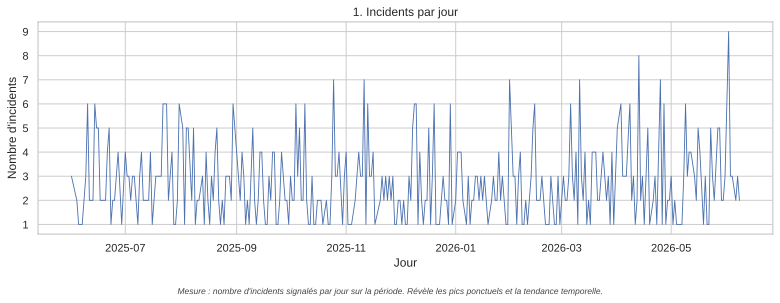

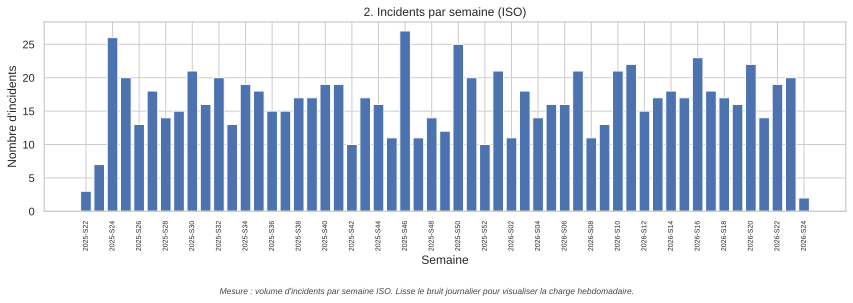

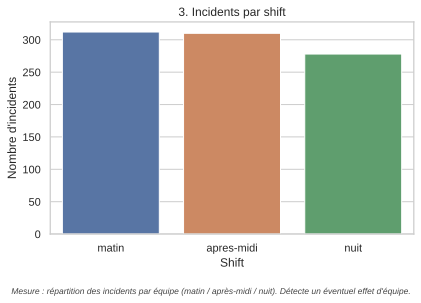

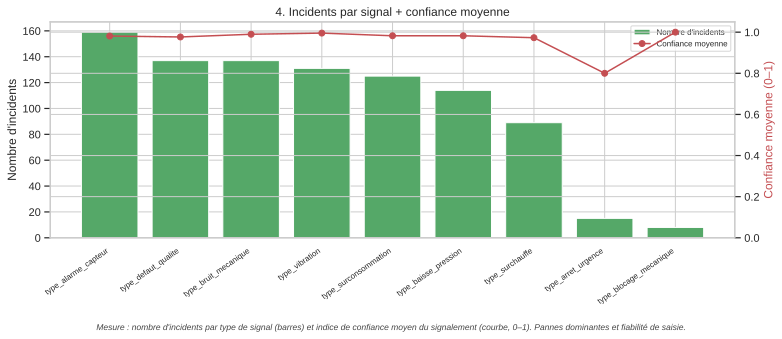

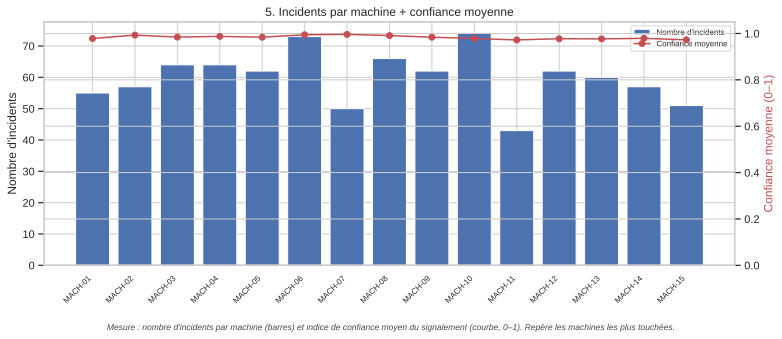

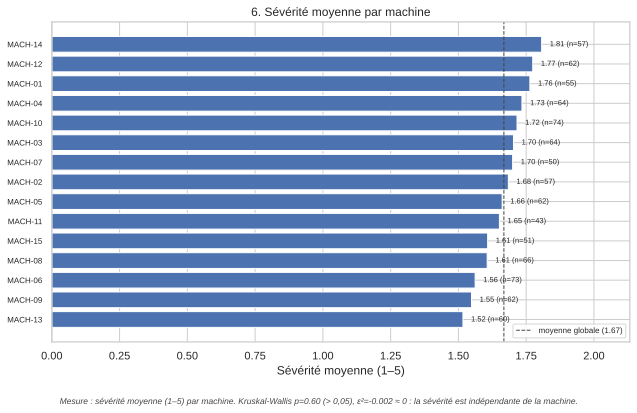

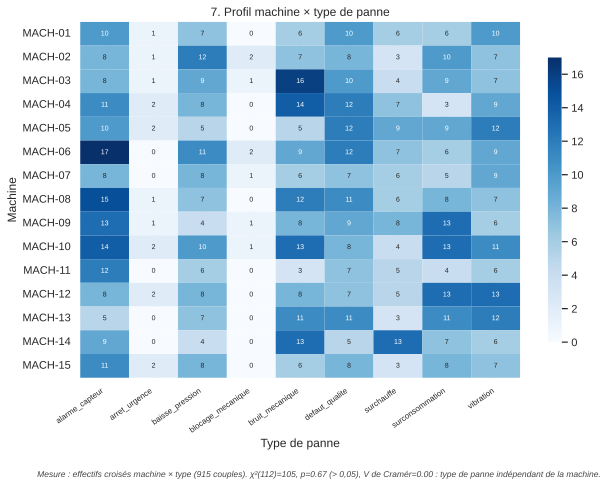

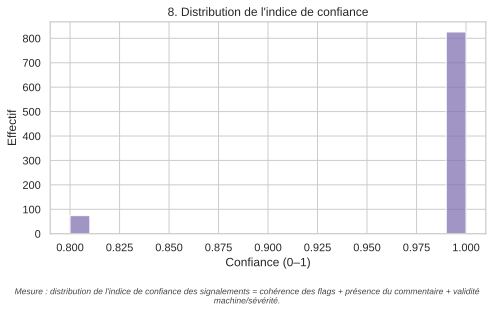

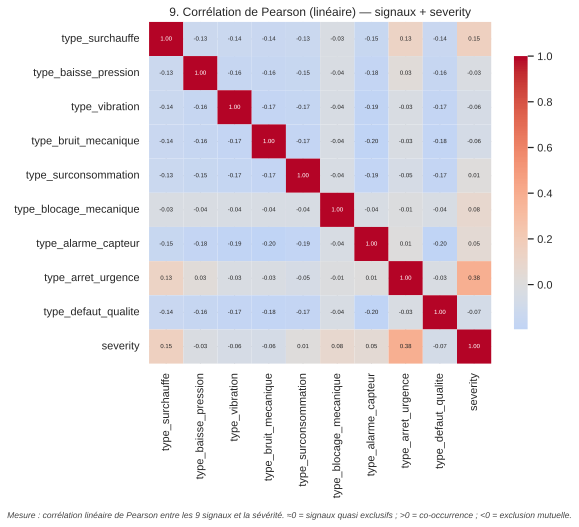

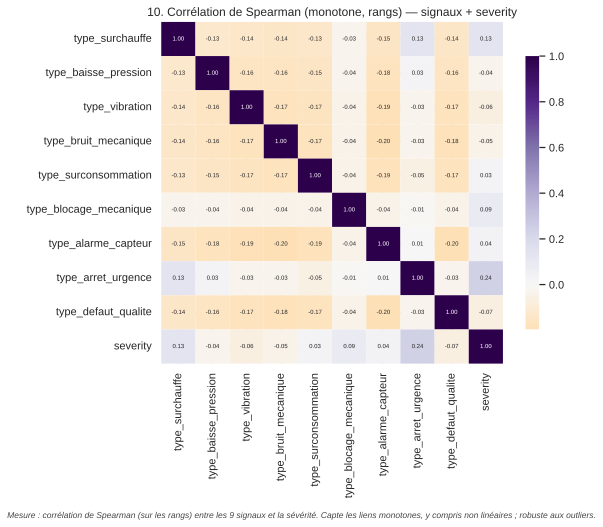

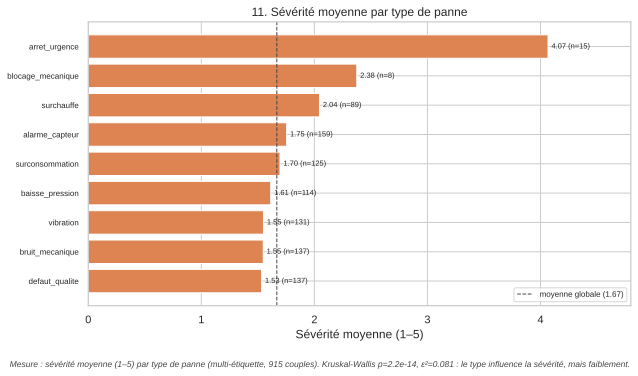

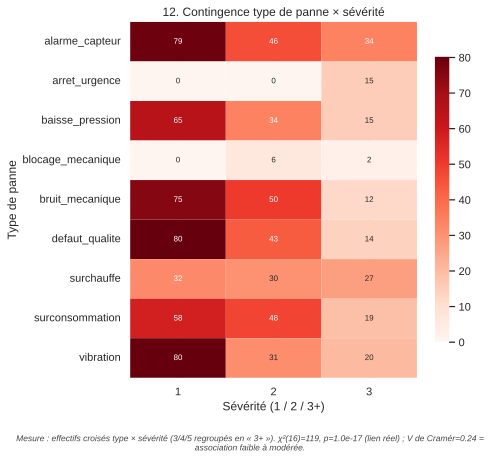

In [8]:
from IPython.display import SVG, display

from indusense import config

run_dir = sorted(p for p in config.ANALYSE_INCIDENTS_DIR.glob("2*") if p.is_dir())[-1]
# Fichiers préfixés NN_ : le tri alphabétique = l'ordre d'analyse.
for fig_path in sorted((run_dir / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 5. Contrôle : relation entre le commentaire et les flags

`comment` est une **saisie guidée**. On vérifie sa correspondance avec les flags `type_*` :

- **Correspondance déterministe** : 1 seul commentaire distinct par signal, **aucune
  contradiction** (0 commentaire ne pointe vers plusieurs signaux). Bonne qualité de saisie.
- Cas particulier : **`type_arret_urgence` n'apparaît jamais seul** — c'est un marqueur
  d'escalade, encodé dans le commentaire par « … **+ arrêt ligne** ».
- Seul écart : 59 commentaires manquants (NaN), répartis aléatoirement sur les signaux.

➡️ **Conséquence** : le commentaire est une **redondance documentaire** des flags (label
lisible). Précieux pour la **validation croisée / l'audit**, mais **à exclure des features
ML** (colinéarité parfaite + risque de *data leakage* : le commentaire *est* l'étiquette
de la panne).

In [9]:
# 1) Correspondance signal -> commentaire (incidents mono-signal)
mono = incidents[incidents["n_signals"] == 1]
recap = (
    mono.groupby("signal")["comment"].agg(
        n="size",
        commentaires_distincts=lambda s: s.nunique(dropna=True),
        nan=lambda s: int(s.isna().sum()),
        exemple=lambda s: s.dropna().iloc[0] if s.notna().any() else None,
    )
)
display(recap)

# 2) Cohérence : un commentaire pointe-t-il vers plusieurs signaux ?
amb = mono.dropna(subset=["comment"]).groupby("comment")["signal"].nunique()
print("Commentaires liés à plusieurs signaux :", int((amb > 1).sum()), "/", amb.shape[0])

# 3) type_arret_urgence : jamais seul (marqueur d'escalade "+ arrêt ligne")
print(
    "arret_urgence — total:", int(incidents["type_arret_urgence"].sum()),
    "| en mono-signal:",
    int(incidents[(incidents.type_arret_urgence == 1) & (incidents.n_signals == 1)].shape[0]),
)

,n,commentaires_distincts,nan,exemple
signal,,,,
type_alarme_capteur,156,1,12,alarme capteur
type_baisse_pression,111,1,7,micro-fuite / baisse pression
type_blocage_mecanique,8,1,0,pièce bloquée convoyeur
type_bruit_mecanique,136,1,6,bruit mécanique anormal
type_defaut_qualite,136,1,15,défaut qualité pièces
type_surchauffe,83,1,6,chauffe anormale
type_surconsommation,125,1,11,surconsommation électrique
type_vibration,130,1,2,vibration excessive


Commentaires liés à plusieurs signaux : 0 / 8
arret_urgence — total: 15 | en mono-signal: 0


### 6. Corrélation entre sévérité et type de panne

La sévérité est **ordinale** (1–5) et le type de panne **nominal** (multi-étiquette) :
Pearson/Spearman ne s'appliquent pas. On utilise les tests adaptés (cf. `METHODOLOGIE.md`) :
**χ² + V de Cramér** (force du lien entre deux variables catégorielles) et
**Kruskal-Wallis + ε²** (la sévérité varie-t-elle selon le type ?).

➡️ **Conclusion** : association **statistiquement significative mais faible à modérée**
(V de Cramér ≈ 0,24). Elle est portée par quelques types extrêmes — `arret_urgence`
(quasi toujours critique), puis `surchauffe` / `blocage_mecanique` — alors que la majorité
des types se concentrent dans une sévérité basse et homogène (≈ 1,5). **Le type seul ne
suffit donc pas à prédire la sévérité** : les variables de télémétrie resteront nécessaires.

Voir les figures *Sévérité moyenne par type* et *Contingence type × sévérité* ci-dessus (§4).

In [10]:
assoc = ing.severity_type_association(incidents)

print(f"Couples (incident x type) : {assoc['n_couples']}")
print(
    f"Chi2({assoc['dof']}) = {assoc['chi2']:.1f}  p = {assoc['p_chi2']:.2e}"
    f"  |  V de Cramer = {assoc['cramers_v']:.3f}"
    f"  (cellules exp.<5 : {assoc['cellules_exp_faibles']})"
)
print(
    f"Kruskal-Wallis H = {assoc['kruskal_H']:.1f}  p = {assoc['p_kruskal']:.2e}"
    f"  |  epsilon^2 = {assoc['epsilon2']:.3f}"
)

# Sévérité moyenne par type (du plus grave au moins grave)
assoc['sev_par_type'].round(3)

Couples (incident x type) : 915
Chi2(16) = 118.5  p = 1.04e-17  |  V de Cramer = 0.237  (cellules exp.<5 : 5)
Kruskal-Wallis H = 81.8  p = 2.16e-14  |  epsilon^2 = 0.081


,count,mean,std
type_panne,,,
arret_urgence,15,4.067,0.258
blocage_mecanique,8,2.375,0.744
surchauffe,89,2.045,0.999
alarme_capteur,159,1.755,0.877
surconsommation,125,1.696,0.743
baisse_pression,114,1.614,0.857
vibration,131,1.550,0.767
bruit_mecanique,137,1.547,0.675
defaut_qualite,137,1.533,0.718


### 7. Étude statistique par machine

On décline l'analyse sur la dimension **machine** (`machine_association`, cf.
`METHODOLOGIE.md`) : **Kruskal-Wallis** (la sévérité dépend-elle de la machine ?) et
**χ² + V de Cramér** (le type de panne dépend-il de la machine ?).

➡️ **Conclusion** : ni la sévérité (Kruskal **p ≈ 0,60**), ni le type de panne (χ²
**p ≈ 0,67**, V de Cramér ≈ **0**) ne dépendent de la machine. Le parc est **homogène** —
aucune machine ne se distingue par un profil de pannes ou une gravité particulière.
Voir les figures *6. Sévérité moyenne par machine* et *7. Profil machine × type* (§4).


In [11]:
m_assoc = ing.machine_association(incidents)

print(f"Machines : {m_assoc['n_machines']} | couples (incident x type) : {m_assoc['n_couples']}")
print(
    f"Kruskal-Wallis severite~machine : H={m_assoc['kruskal_H']:.1f}"
    f"  p={m_assoc['p_kruskal']:.2f}  epsilon^2={m_assoc['epsilon2']:.3f}"
)
print(
    f"Chi2 machine x type : chi2={m_assoc['chi2']:.0f} (dof={m_assoc['dof']})"
    f"  p={m_assoc['p_chi2']:.2f}  V de Cramer={m_assoc['cramers_v']:.3f}"
    f"  (cellules exp.<5 : {m_assoc['cellules_exp_faibles']})"
)

# Sévérité moyenne par machine (du plus grave au moins grave)
m_assoc['sev_par_machine'].round(3)

Machines : 15 | couples (incident x type) : 915
Kruskal-Wallis severite~machine : H=12.0  p=0.60  epsilon^2=-0.002
Chi2 machine x type : chi2=105 (dof=112)  p=0.67  V de Cramer=0.000  (cellules exp.<5 : 32)


,count,mean,std
machine_id,,,
MACH-14,57,1.807,0.811
MACH-12,62,1.774,0.798
MACH-01,55,1.764,0.793
MACH-04,64,1.734,0.913
MACH-10,74,1.716,0.836
MACH-03,64,1.703,0.830
MACH-07,50,1.700,0.814
MACH-02,57,1.684,0.805
MACH-05,62,1.661,0.922


### Livrables produits

| Livrable | Emplacement |
|---|---|
| Dataset anonymisé + enrichi (Parquet) | `artifacts/analyses/incidents/<run>/incidents_anonymized.parquet` |
| 12 graphes SVG annotés | `artifacts/analyses/incidents/<run>/figures/` |
| Métadonnées du run | `artifacts/analyses/incidents/<run>/run_metadata.json` |
| Journal des runs | `artifacts/analyses/incidents/runs.json` · `runs.md` |
| Méthodologie (RGPD + indice de confiance) | `artifacts/analyses/incidents/METHODOLOGIE.md` |

▶️ Reproductible en une commande : `uv run indusense-incidents`.

## Analyse de la télémétrie

Second jeu de données : `telemetry.csv` (relevés capteurs **horaires** : température,
pression, tension, rotation, pièces produites). Pipeline parallèle aux incidents
(`indusense-telemetry`) : vérification RGPD → dédoublonnage → analyse statistique.
Artefacts versionnés sous `artifacts/analyses/telemetry/`.

### 1. Anonymisation & dédoublonnage
- **Anonymisation : non requise** — aucune donnée personnelle (mesures capteurs +
  `machine_id`, identifiant d'**équipement**). Vérifié par `check_no_personal_data`.
- **Dédoublonnage** : clé d'unicité `(machine_id, timestamp)`. Résultat : **0 doublon**,
  grille horaire complète (15 machines × 8 952 h), **0 NaN**.


In [12]:
from indusense.data import telemetry as tel_an

meta_tel = tel_an.run_analysis()
print(f"Run {meta_tel['run_id']}")
print(
    f"  lignes={meta_tel['n_lignes']} machines={meta_tel['machines_uniques']}"
    f"  doublons_retires={meta_tel['n_doublons_supprimes']} NaN={meta_tel['n_nan_total']}"
    f"  outliers={meta_tel['n_outliers_total']}"
)
print(f"  anonymisation requise : {meta_tel['anonymisation_requise']}")
print(f"  periode : {meta_tel['periode_debut']} -> {meta_tel['periode_fin']}")


Run 202606221008
  lignes=134280 machines=15  doublons_retires=0 NaN=0  outliers=1093
  anonymisation requise : False
  periode : 2025-06-01 00:00:00 -> 2026-06-08 23:00:00


### 2. Visualisation (9 figures, ordonnées par usage)

Vue d'ensemble (1–2) → comparaison par machine (3–4) → corrélations (5–6) →
profils temporels (7–8) → lien capteurs ↔ production (9). Fichiers préfixés `NN_`.


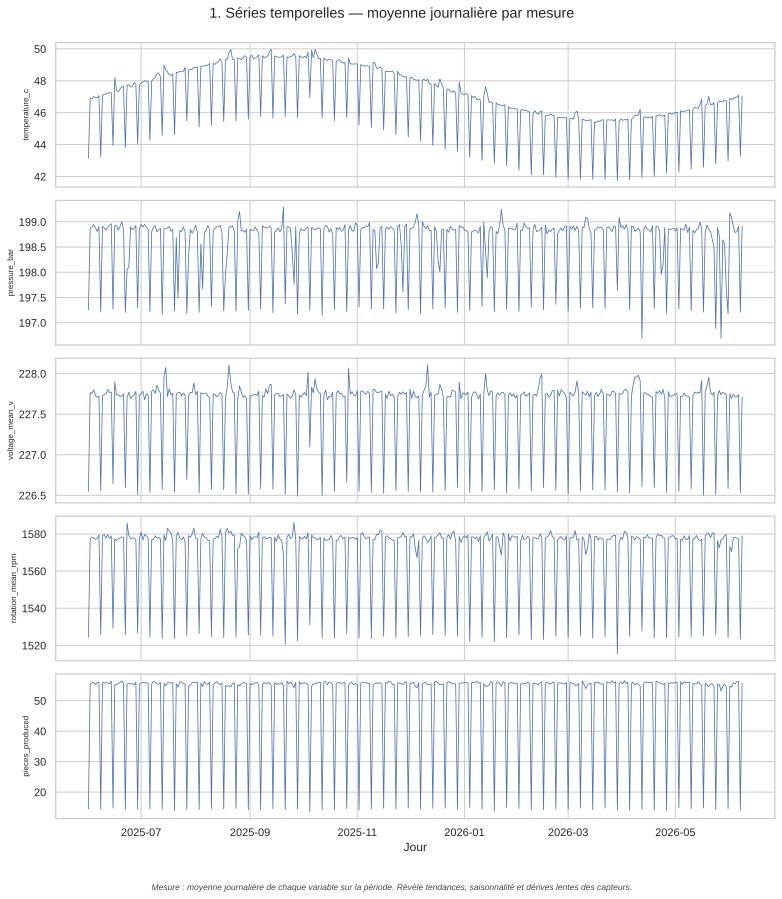

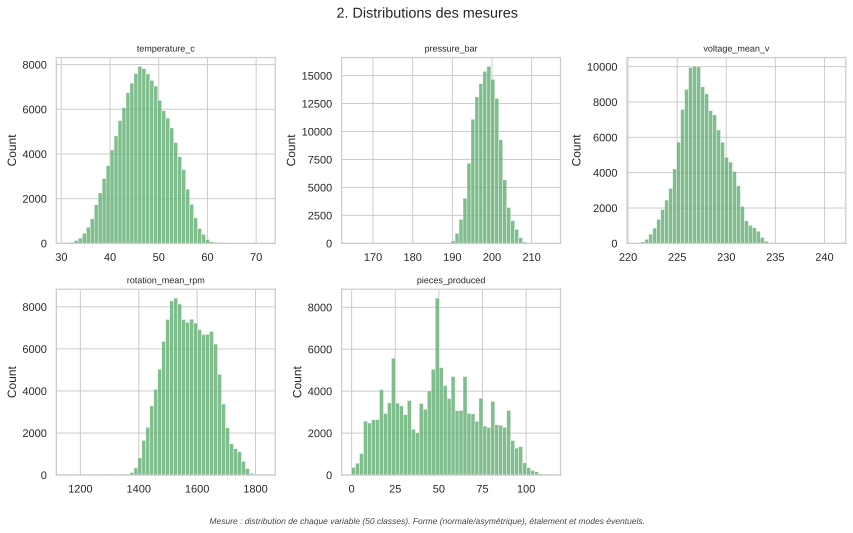

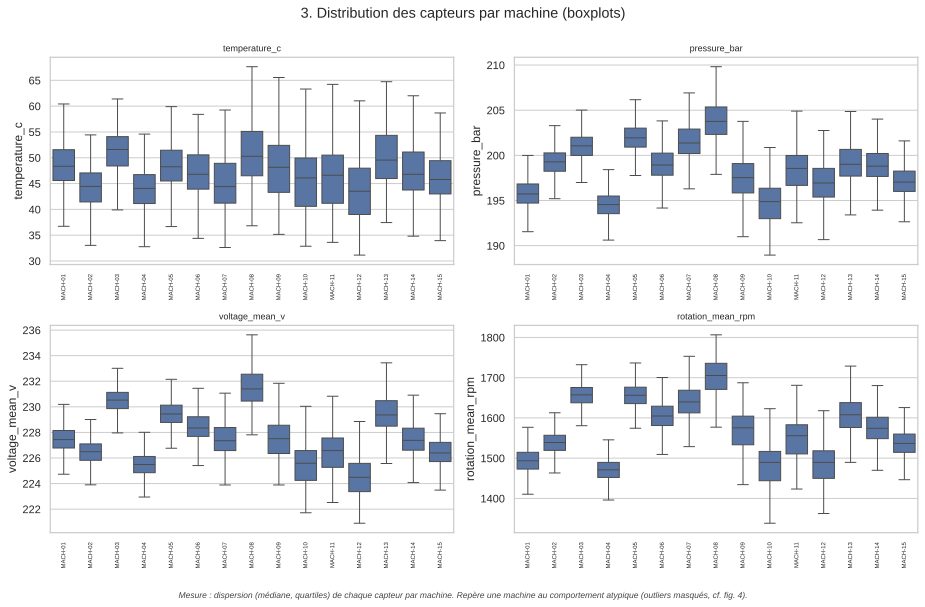

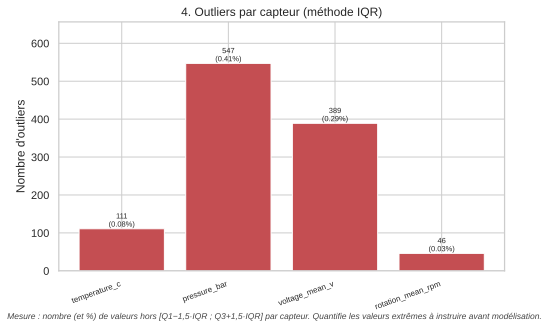

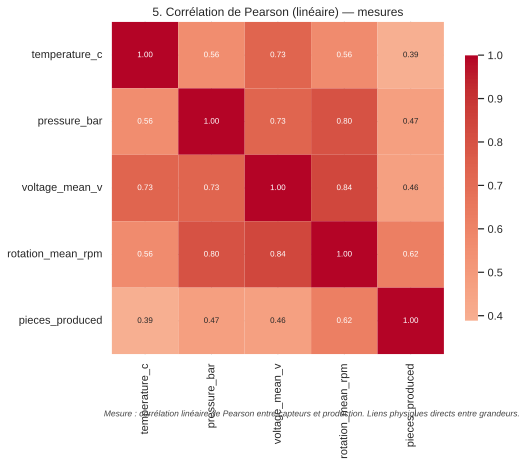

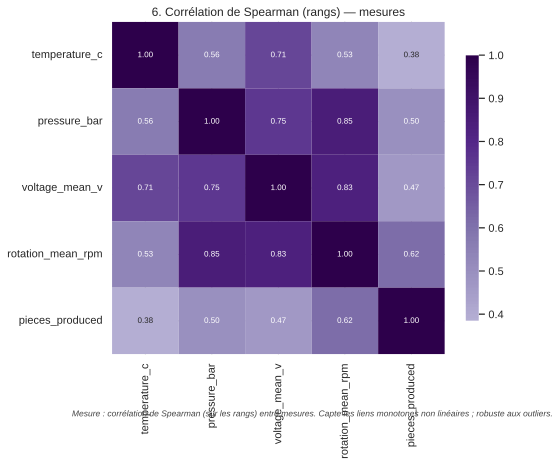

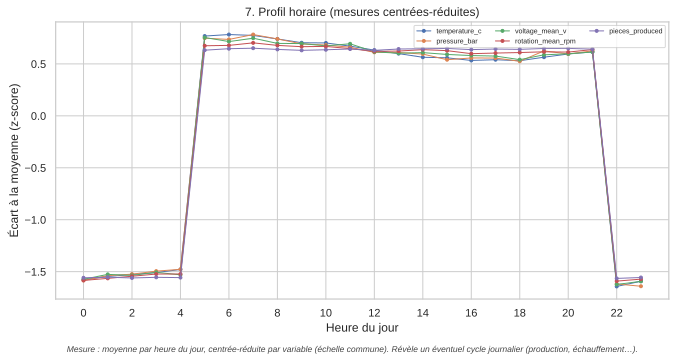

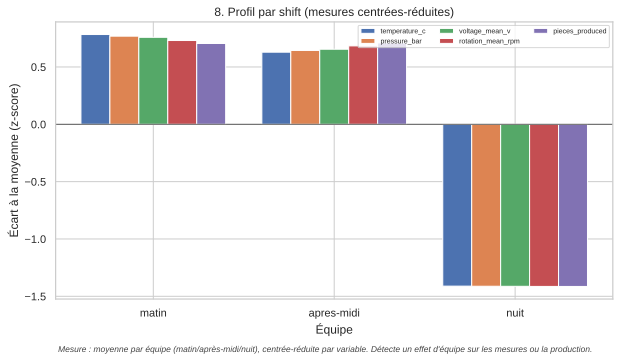

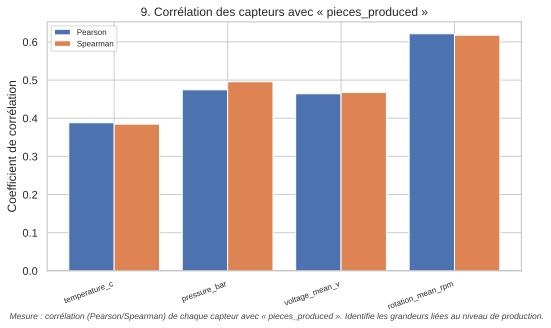

In [13]:
from IPython.display import SVG, display

from indusense import config

tel_run = sorted(p for p in config.ANALYSE_TELEMETRY_DIR.glob("2*") if p.is_dir())[-1]
for fig_path in sorted((tel_run / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 3. Statistiques descriptives, outliers et corrélations


In [14]:
df_tel = tel_an.enrich(tel_an.deduplicate(tel_an.load_telemetry())[0])
stats = tel_an.descriptive_stats(df_tel)
display(stats['global'].round(2))
print('Outliers par capteur (méthode IQR) :')
display(tel_an.detect_outliers(df_tel))
print('Corrélation de Pearson (capteurs + production) :')
tel_an.correlations(df_tel)['pearson'].round(2)


,count,mean,std,min,25%,50%,75%,max
temperature_c,134280.0,47.02,5.23,31.02,43.27,46.96,50.84,71.87
pressure_bar,134280.0,198.58,3.31,164.60,196.31,198.62,200.83,214.78
voltage_mean_v,134280.0,227.59,2.25,220.90,226.03,227.40,229.11,241.16
rotation_mean_rpm,134280.0,1570.33,79.63,1151.80,1509.80,1567.40,1632.20,1833.40
pieces_produced,134280.0,49.69,24.53,0.00,29.00,50.00,68.00,114.00


Outliers par capteur (méthode IQR) :


,borne_basse,borne_haute,n_outliers,pct
temperature_c,31.92,62.20,111,0.08
pressure_bar,189.52,207.61,547,0.41
voltage_mean_v,221.41,233.73,389,0.29
rotation_mean_rpm,1326.20,1815.80,46,0.03


Corrélation de Pearson (capteurs + production) :


,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced
temperature_c,1.00,0.56,0.73,0.56,0.39
pressure_bar,0.56,1.00,0.73,0.80,0.47
voltage_mean_v,0.73,0.73,1.00,0.84,0.46
rotation_mean_rpm,0.56,0.80,0.84,1.00,0.62
pieces_produced,0.39,0.47,0.46,0.62,1.00


➡️ **Conclusions**

- **Qualité** : données déjà propres — 0 doublon, 0 NaN, et seulement **~0,2 %**
  d'outliers (IQR), surtout sur la pression (0,41 %). Aucune suppression à ce stade.
- **Liens inter-capteurs** : les 4 capteurs sont **positivement corrélés** (0,56–0,84) —
  ils décrivent un même **régime d'activité machine** ; les plus forts sont
  tension ↔ rotation (0,84) et pression ↔ rotation (0,80).
- **Production** : la **vitesse de rotation** est le meilleur proxy de `pieces_produced`
  (r ≈ 0,62), devant pression/tension (≈ 0,47). Pearson ≈ Spearman → liens quasi linéaires.
- Ces signaux propres et corrélés sont **exploitables** pour la maintenance prédictive
  (modélisation en couches silver/gold à venir).


## Analyse du référentiel

Troisième source : le **référentiel** (dump SQL fourni `data/raw/machine.sql`, tables
`machine` et `maintenance`), chargé dans `bronze` par `indusense-ingest --migrate`. Le
pipeline `indusense-referentiel` lit la **couche bronze** (médaillon, source unique de
vérité) — comme les pipelines incidents et télémétrie.

### 1. Source, anonymisation & intégrité
- **Anonymisation : non requise** — caractéristiques d'équipement + journal de
  maintenance, aucune donnée personnelle.
- **Intégrité** vérifiée (`check_integrity`) : unicité des PK, intégrité référentielle
  (maintenance → machine), cohérence réactif ↔ incident.


In [15]:
from indusense.data import referentiel as ref_an

meta_ref = ref_an.run_analysis()
print(f"Run {meta_ref['run_id']}")
print(
    f"  machines={meta_ref['n_machines']} maintenances={meta_ref['n_maintenances']}"
    f"  modeles={meta_ref['n_modeles']} proactive={meta_ref['n_proactive']}"
    f"  reactive={meta_ref['n_reactive']}"
)
meta_ref['integrite']


Run 202606221008
  machines=15 maintenances=115  modeles=4 proactive=90  reactive=25


{'machine_pk_unique': True,
 'maintenance_pk_unique': True,
 'machines_orphelines': [],
 'reactive_sans_incident': 0,
 'colonnes_dcp': [],
 'anonymisation_requise': False}

### 2. Visualisation (9 figures, ordonnées par usage)

Parc machines (1–4 : modèle, attributs, capacité, ancienneté) → activité de
maintenance (5–9 : type, par machine, composants, durée, saisonnalité).


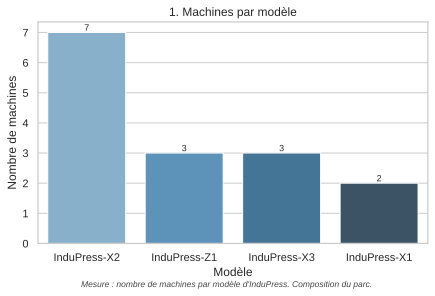

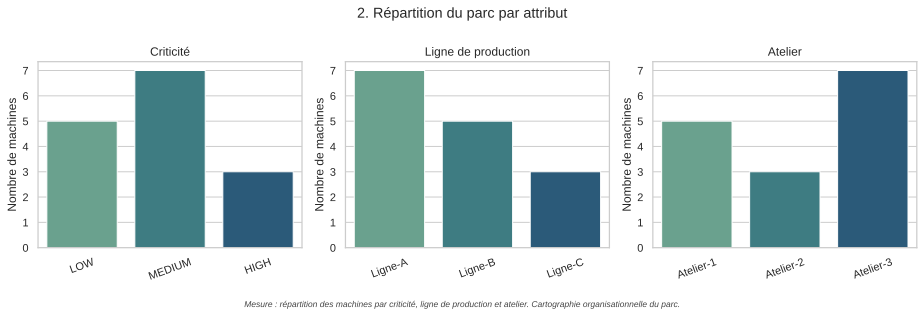

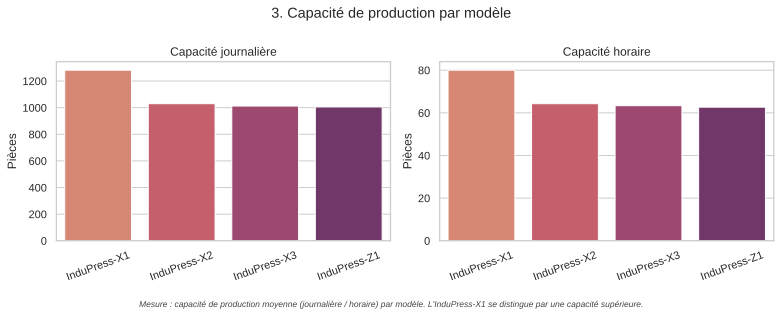

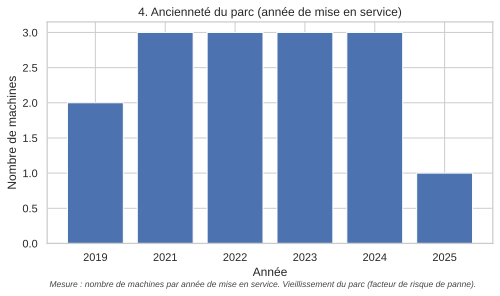

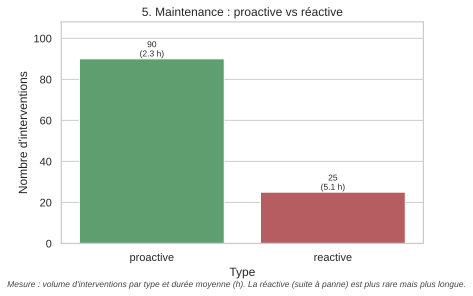

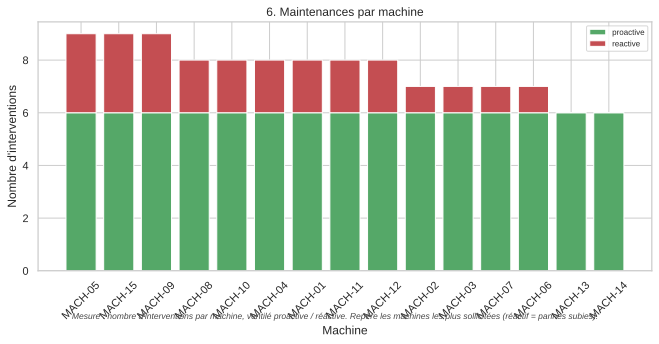

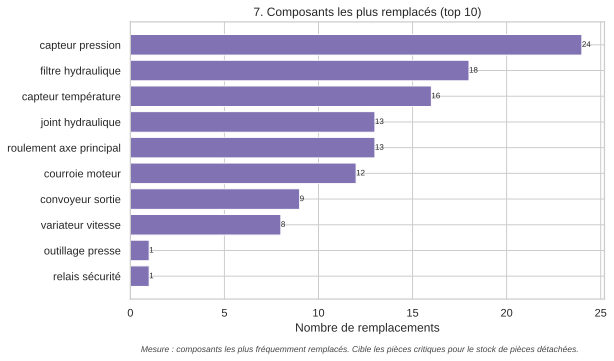

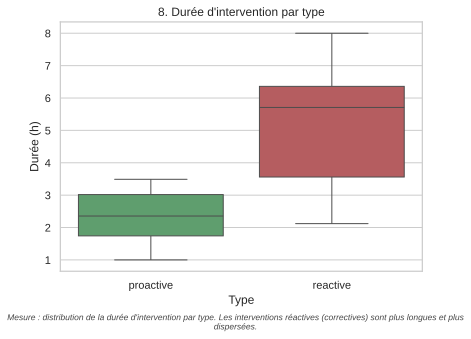

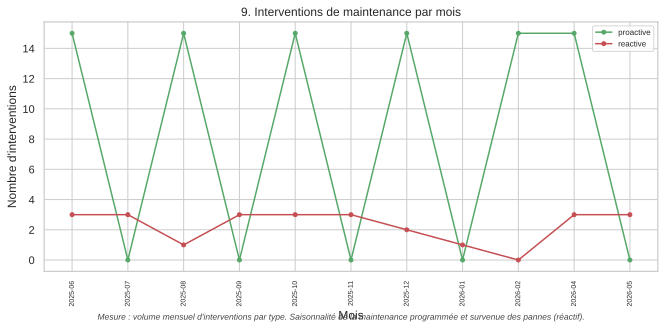

In [16]:
from IPython.display import SVG, display

from indusense import config

ref_run = sorted(p for p in config.ANALYSE_REFERENTIEL_DIR.glob("2*") if p.is_dir())[-1]
for fig_path in sorted((ref_run / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 3. Tableaux de synthèse


In [17]:
machine, maintenance = ref_an.load_referentiel()
print('Répartition par modèle :')
display(ref_an.machine_distributions(machine)['model'])
print('Capacité moyenne par modèle :')
display(ref_an.capacity_by_model(machine).round(0))
summ = ref_an.maintenance_summary(maintenance)
print('Maintenance par type (durée en h) :')
display(summ['par_type'].round(2))
print('Top composants remplacés :')
summ['composants'].head(8)


Répartition par modèle :


model
InduPress-X2    7
InduPress-Z1    3
InduPress-X3    3
InduPress-X1    2
Name: count, dtype: int64

Capacité moyenne par modèle :


,max_daily_capacity,max_hourly_capacity_pieces
model,,
InduPress-X1,1282.0,80.0
InduPress-X2,1030.0,64.0
InduPress-X3,1012.0,63.0
InduPress-Z1,1005.0,63.0


Maintenance par type (durée en h) :


,count,mean,min,max
maintenance_type,,,,
proactive,90,2.34,1.00,3.49
reactive,25,5.12,2.12,8.00


Top composants remplacés :


component
capteur pression           24
filtre hydraulique         18
capteur température        16
roulement axe principal    13
joint hydraulique          13
courroie moteur            12
convoyeur sortie            9
variateur vitesse           8
Name: count, dtype: int64

➡️ **Conclusions**

- **Parc** : 15 machines, 4 modèles (`InduPress-X2` majoritaire : 7 ; `X1` minoritaire :
  2 mais **plus capacitaire**). Criticité MEDIUM (7) / LOW (5) / HIGH (3) ; parc mis en
  service entre 2019 et 2025, toutes actives.
- **Maintenance** : **90 proactives** (préventif programmé) vs **25 réactives**
  (correctif sur panne), soit ~78 % / 22 %. La réactive est **~2× plus longue**
  (5,1 h vs 2,3 h) — le correctif coûte cher en immobilisation.
- **Composants** : les **capteurs (pression, température)** dominent les remplacements,
  cohérent avec les signaux d'incidents (`alarme_capteur`, `baisse_pression`).
- **Traçabilité** : les 25 maintenances réactives sont **toutes liées à un incident**
  (`related_incident_id`) ; `action_type` est redondant avec `maintenance_type`.
- **Enjeu** : la maintenance prédictive vise à **basculer du réactif (coûteux) vers le
  proactif ciblé** — d'où l'intérêt de relier télémétrie, incidents et maintenance.
